# Hybrid: Clustering + Classification (Leakage-Safe)

Pipeline following requested diagram with train/test split before clustering, KMeans fitted on TRAIN only, cluster as feature, SMOTE on TRAIN, classifier trained on resampled TRAIN, evaluation on TEST.

In [3]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

sys.path.append(os.path.abspath(".."))

from src import TARGET, data_split , get_preprocessor , loader

In [4]:
df = loader()
df["Churn"] = df["Churn"].astype(str)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
X_train, X_test, y_train, y_test = data_split(df, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)
print(pd.Series(y_train).value_counts(), pd.Series(y_test).value_counts())

(5634, 20) (1409, 20)
Churn
0    4138
1    1496
Name: count, dtype: int64 Churn
0    1036
1     373
Name: count, dtype: int64


In [6]:
preprocessor = get_preprocessor()
preprocessor.fit(X_train)
X_train_pre = pd.DataFrame(preprocessor.transform(X_train), columns=preprocessor.get_feature_names_out(), index=X_train.index)
X_train_pre.head()

,numerical__tenure,numerical__MonthlyCharges,numerical__TotalCharges,categorical__MultipleLines_No,categorical__MultipleLines_No phone service,categorical__MultipleLines_Yes,categorical__InternetService_DSL,categorical__InternetService_Fiber optic,categorical__InternetService_No,categorical__OnlineSecurity_No,...,categorical__PaymentMethod_Bank transfer (automatic),categorical__PaymentMethod_Credit card (automatic),categorical__PaymentMethod_Electronic check,categorical__PaymentMethod_Mailed check,binary__SeniorCitizen,binary__Partner,binary__Dependents,binary__PhoneService,binary__PaperlessBilling,gender__gender
2142,-0.465683,-0.000474,-0.422105,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0,0,1,1,0,0
1623,0.885537,1.074754,1.25536,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0,0,0,1,1,0
6074,-1.284605,-1.376499,-1.002991,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0,1,0,0,1,1
1362,-1.161766,0.177346,-0.908119,1.0,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0,0,0,1,1,1
6754,-1.325551,-0.098524,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0,0,1,1,1,1


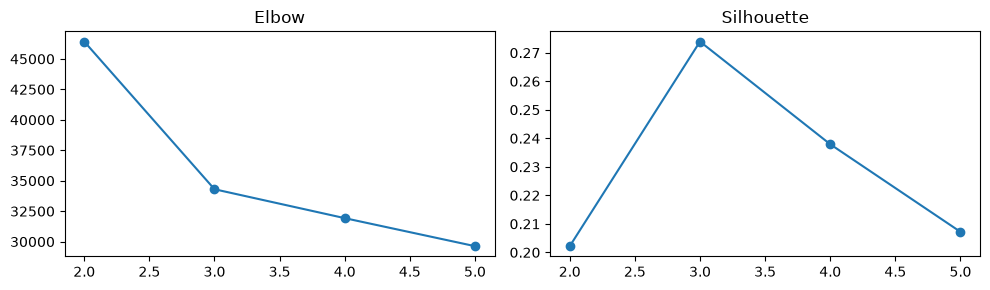

In [7]:
from sklearn.metrics import silhouette_score
k_range = range(2, 6)
wcss, sil = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labs = km.fit_predict(X_train_pre.values)
    wcss.append(km.inertia_)
    sil.append(silhouette_score(X_train_pre.values, labs))

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(k_range, wcss, marker='o')
axes[0].set_title('Elbow')
axes[1].plot(k_range, sil, marker='o')
axes[1].set_title('Silhouette')
plt.tight_layout(); plt.show()

In [8]:
K = 3
kmeans = KMeans(n_clusters=K, random_state=42, n_init='auto')
kmeans.fit(X_train_pre.values)
train_clusters = kmeans.predict(X_train_pre.values)
pd.Series(train_clusters).value_counts().sort_index()

0    1214
1    1877
2    2543
Name: count, dtype: int64

In [9]:
X_train_feat = X_train_pre.copy()
X_train_feat['cluster'] = train_clusters.astype(int)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_feat.values, y_train.values)
X_train_res = pd.DataFrame(X_train_res, columns=X_train_feat.columns)
pd.Series(y_train_res).value_counts()

0    4138
1    4138
Name: count, dtype: int64

In [10]:
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_res, y_train_res)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

In [11]:
X_test_pre = pd.DataFrame(preprocessor.transform(X_test), columns=preprocessor.get_feature_names_out(), index=X_test.index)
test_clusters = kmeans.predict(X_test_pre.values)
X_test_feat = X_test_pre.copy()
X_test_feat['cluster'] = test_clusters.astype(int)

y_pred = clf.predict(X_test_feat.values)
y_proba = clf.predict_proba(X_test_feat.values)[:, 1]

print(classification_report(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.92      0.73      0.81      1036
           1       0.52      0.83      0.64       373

    accuracy                           0.76      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.82      0.76      0.77      1409

ROC AUC: 0.8606790915772149


/home/fangyuan/Projects/telco-customer-segmentation-churn/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/home/fangyuan/Projects/telco-customer-segmentation-churn/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


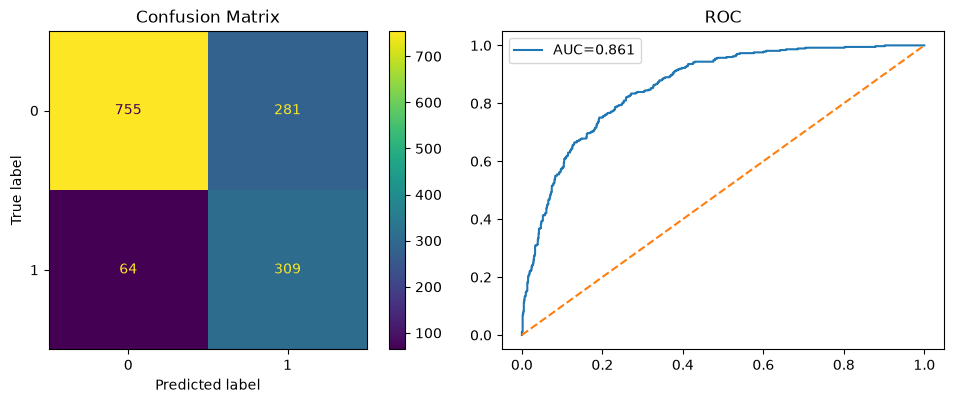

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred)).plot(ax=axes[0])
axes[0].set_title('Confusion Matrix')
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f'AUC={roc_auc_score(y_test, y_proba):.3f}')
axes[1].plot([0,1],[0,1],'--')
axes[1].legend()
axes[1].set_title('ROC')
plt.tight_layout(); plt.show()